In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [4]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [5]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [89]:
degs = (2,3,5,8)
maxpatches =(20000,15000,15000,12000)
level = (2,2,2,2)
maxiter=30
eps=1e-5
maxN=0

direct=False

prim = {'v':1, 'e':0}
R = np.zeros((1000,5*len(degs)))

example=1

f=1
g=0

plot=0
dir_data={0:g}
U=[]
eta=[]

for i,deg in enumerate(degs):
    N = deg+1
    M = LshapeAnullus(deg,N,1)

    IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=0)
    eta=1.0
    k=0
    while k<maxiter:
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            plt.show();
            plt.close();

        ### SOLVE
        A, RHS = IMap.assemble(a=1,f=f, M=None)
        N = [A.shape[0] for A in A]
            
        Prim = csc_matrix((IMap.N_ofs_elim[-1],0))

        if bool(prim['v']):
            PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
            Prim = scipy.sparse.hstack([Prim, PrimV])
        if bool(prim['e']):
            Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals(1)])

        B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
        SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

        nPrim=Prim.shape[1]

        R[k,i*5+3]=nPrim
        R[k,i*5+4]=IMap.nPatches

        if nPrim==0:
            I = ieti.IetiSystem(A, B, RHS, N)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()
            C = [scipy.sparse.csr_matrix((0,A[p].shape[1])) for p in range(len(B))]
        else:
            primal = ieti.PrimalSystem(Prim)
            modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
            loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
            modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
            loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
            I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()

        SD.setupSelectionScaling()
        #SD.SchurAsMatrices()
        #SD.setupConstraintScaling()
        
        Prec1 = SD.AsOperator()
        #Prec2=ieti.EdgePreconditioner(IMap, SD.S_dense, SD.B ,C)#@np.eye(F.shape[0])
        
        lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=Prec1, output=1, rtol=1e-8, atol=1e-12)
        R[k,i*5+1] = it
        R[k,i*5+2] = max_eig/min_eig

        uh = I.constructSolutionFromLagrangeMultipliers(lam)
        if nPrim>0:
            uh = primal.distributePrimalSolution(uh)
        uh = np.concatenate(IMap.completeDirichlet(uh))
        if IMap.elim:
            uh = IMap.Basis_loc_global@uh

        # U.append(u)

        # dir_bcs = IMap.set_fixed_boundary(dir_data, local=False)
        # Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
        # Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        # Fh = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        # LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        # uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        # u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
        # u_exact = operators.make_solver(Mh,spd=True)@u_load
        # eh = u_exact-uh
        # U.append(uh)

        # L2err = np.sqrt(eh.T@Mh@eh)
        # Eerr = np.sqrt(eh.T@Kh@eh)

        # if plot:
        #     IMap.plot(uh,mesh=True)
        #     plt.show()

        err_ind=adaptive.mp_resPois(IMap, uh, nu=1, f=f)
        eta = np.linalg.norm(err_ind)
        #eta.append(eta)
        R[k,i*5] = eta
        #print(eta[-1]/Eerr)

        print("Error Estimator: {:.3}".format(eta))
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if IMap.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps:
            break;

        P = IMap.h_refine(h_ref=marked_patches,ref="rs", return_P = True, in_subspace=True)
        # for m in range(len(U)):
        #     U[m] = P@U[m]

        k+=1
        print("#####################################################")

    maxN = max(maxN,k)
R=R[:maxN,:]
np.save("LshapeD_B",R)
    # P = IMap.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
    # P = IMap.p_refine(return_P = True, in_subspace=True)@P

    # L2err = np.zeros(len(U))
    # Eerr = np.zeros(len(U))
    
    # Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
    # Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)

    # u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
    # u_exact = operators.make_solver(Mh,spd=True)@u_load

    # for m in range(len(U)):
    #     eh = u_exact - P@U[m] 

    #     L2err[m]= np.sqrt(eh.T@Mh@eh)
    #     Eerr[m] = np.sqrt(eh.T@Kh@eh)

setting up constraints took 0.00275421142578125 seconds.
Basis setup took 0.0018436908721923828 seconds
pcg with preconditioned condition number κ ~ 1.536 stopped after 5 iterations with relres 4.201e-10 after 0.0249 seconds.
Error Estimator: 0.0382
setting up constraints took 0.0203096866607666 seconds.
Basis setup took 0.0026857852935791016 seconds
#####################################################
pcg with preconditioned condition number κ ~ 3.807 stopped after 13 iterations with relres 5.577e-09 after 0.0878 seconds.
Error Estimator: 0.0348
setting up constraints took 0.02746295928955078 seconds.
Basis setup took 0.001734018325805664 seconds
#####################################################
pcg with preconditioned condition number κ ~ 6.452 stopped after 17 iterations with relres 5.554e-09 after 0.205 seconds.
Error Estimator: 0.0239
setting up constraints took 0.05276918411254883 seconds.
Basis setup took 0.002382040023803711 seconds
########################################

KeyboardInterrupt: 

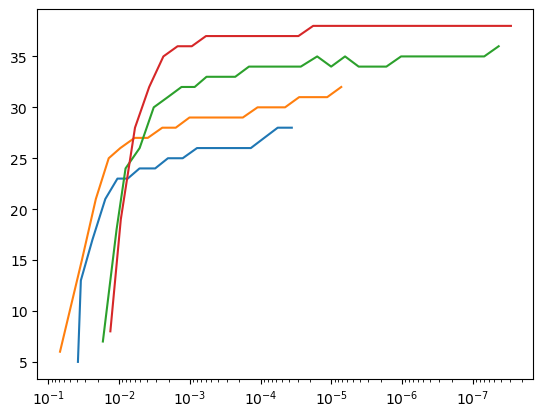

In [85]:
R = np.load("LshapeS_A.npy")
for i in range(4):
    data = R[:,i*5+np.array([0,1])]
    rows_nonzero = np.any(data != 0, axis=1)

    if np.any(rows_nonzero):
        last = np.flatnonzero(rows_nonzero)[-1]
        data = data[:last + 1]
    else:
        data = data[:0]  # all rows are zero
    eta = data[:,0]
    it = data[:,1]
    plt.semilogx(eta,it)
plt.gca().invert_xaxis()
plt.show()

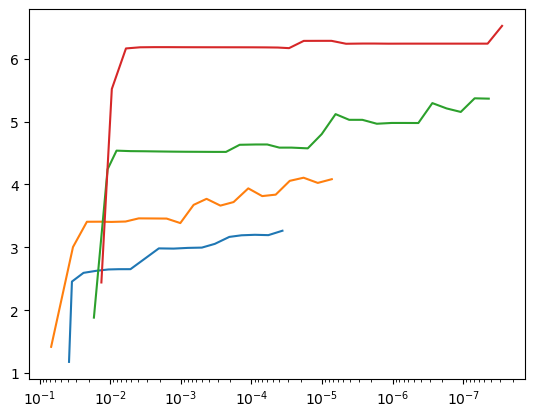

In [82]:
R = np.load("LshapeS_B.npy")
for i in range(4):
    data = R[:,i*5+np.array([0,2])]
    rows_nonzero = np.any(data != 0, axis=1)

    if np.any(rows_nonzero):
        last = np.flatnonzero(rows_nonzero)[-1]
        data = data[:last + 1]
    else:
        data = data[:0]  # all rows are zero
    eta = data[:,0]
    it = data[:,1]
    plt.semilogx(eta,it)
plt.gca().invert_xaxis()
plt.show()

In [74]:
R[:,:2]

array([[3.82477e-02, 4.00000e+00],
       [3.47821e-02, 1.10000e+01],
       [2.38572e-02, 1.20000e+01],
       [1.56870e-02, 1.30000e+01],
       [1.05756e-02, 1.30000e+01],
       [7.57590e-03, 1.30000e+01],
       [5.15664e-03, 1.30000e+01],
       [3.09932e-03, 1.30000e+01],
       [2.04492e-03, 1.40000e+01],
       [1.26509e-03, 1.40000e+01],
       [7.93870e-04, 1.40000e+01],
       [5.02894e-04, 1.40000e+01],
       [3.29545e-04, 1.40000e+01],
       [2.05329e-04, 1.50000e+01],
       [1.37729e-04, 1.50000e+01],
       [8.90672e-05, 1.50000e+01],
       [5.74663e-05, 1.50000e+01],
       [3.63130e-05, 1.50000e+01],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00],
       [0.00000e+00,